In [1]:
# ==============================
# CELL 1: Import libraries
# ==============================

import pandas as pd
import numpy as np
import zipfile

from pyspark.sql import SparkSession
from pyspark.ml import PipelineModel

from scipy.optimize import minimize

print("Libraries loaded")

Libraries loaded


In [2]:
# ==============================
# CELL 2: Unzip model
# ==============================

with zipfile.ZipFile("rf_profit_model.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Model unzipped")

Model unzipped


In [3]:
# ==============================
# CELL 3: Load Spark and trained model
# ==============================

spark = SparkSession.builder.appName("Mazra3ti").getOrCreate()

rf_model = PipelineModel.load("rf_profit_model")

print("Model loaded successfully")

Model loaded successfully


In [4]:
# ==============================
# CELL 4: Load dataset
# ==============================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

df = pd.read_csv("mazra3ti_dataset.csv")

print("Dataset loaded")
df.head()

Dataset loaded


,record_id,crop_name,planting_date,harvest_date,season,area_size,quantity_sold,inventory_remaining,unit_price,total_sales,total_expenses,fertilizer_used,water_used,actual_yield,profit,sale_date,sale_gap_days,market_location,farm_location,region_type,distance_to_market,transport_cost,customer_type,market_price,temperature,humidity,rainfall,wind_speed,pest_indicator,water_efficiency,fertilizer_efficiency,demand_score,demand_level,supply_score,supply_level,sufficiency_status
0,1,Peach,2023-03-01,2023-07-24,Spring,109.56,170.90,17.95,3.752,641.22,198.70,34.50,784.22,188.85,442.52,2023-08-20,27,Maan,Ajloun,Rural,193.04,3.04,Trader,3.806,21.2,64.0,13.2,8.2,False,0.2408,5.4747,0.1947,Low,0.3808,Medium,Surplus
1,2,Zucchini,2022-03-11,2022-05-22,Spring,38.22,56.23,8.22,1.462,82.21,68.11,12.82,338.63,64.45,14.10,2022-05-26,4,Balqa,Maan,Rural,105.31,2.81,Local Market,1.566,23.6,60.4,36.5,10.9,False,0.1903,5.0273,0.5495,Medium,0.2042,Low,Shortage
2,3,Eggplant,2023-06-06,2023-09-27,Summer,37.18,63.94,4.20,1.461,93.45,74.47,8.78,365.27,68.15,18.99,2023-10-25,28,Irbid,Madaba,Urban,120.96,1.36,Local Market,1.447,25.6,31.7,3.3,3.0,False,0.1866,7.7613,0.2333,Low,0.2524,Low,Balanced
3,4,Beans,2020-04-08,2020-06-19,Spring,39.60,37.39,1.54,2.946,110.15,100.97,16.79,361.64,38.93,9.19,2020-06-22,3,Tafilah,Ajloun,Rural,213.64,3.40,Export,3.120,28.4,42.2,33.3,8.0,False,0.1077,2.3186,0.8411,High,0.1586,Low,Shortage
4,5,Lentils,2025-11-04,2026-03-13,Winter,56.67,8.59,0.38,2.543,21.83,87.84,15.06,542.06,8.97,-66.01,2026-04-04,22,Maan,Aqaba,Desert,31.36,0.36,Trader,2.516,31.7,34.3,5.3,16.8,False,0.0165,0.5955,0.3212,Low,0.1722,Low,Shortage


In [5]:
# ==============================
# CELL 5: User inputs
# ==============================

# Total farm area
user_area = 1000.0

# Crops selected by the user
selected_crops = [
    "Tomato", "Orange", "Rice",
    "Banana", "Potato", "Apple"
]

# Bounds
min_share = 0.05   # each selected crop can take at least 5%
max_share = 0.40   # each selected crop can take at most 40%

# Penalty strength for concentration
lambda_penalty = 12000

# Optional farm resource limits
water_limit = 450000
fertilizer_limit = 35000

# User scenario inputs for prediction
user_inputs = {
    "farm_location": "Zarqa",
    "fertilizer_used": 25.0,
    "water_used": 400.0,
    "actual_yield": 80.0,
    "market_price": 2.5,
    "supply_level": 100.0,
    "humidity": 45.0,
    "rainfall": 10.0,
    "wind_speed": 8.0,
    "demand_level_ord": 1,
    "planting_year": 2024,
    "planting_month": 6,
    "planting_day": 1,
    "sale_year": 2024,
    "sale_month": 9,
    "sale_day": 1
}

print("User inputs ready")

User inputs ready


In [6]:
# ==============================
# CELL 6: Build prediction dataset
# ==============================

rows = []

for crop in selected_crops:
    rows.append({
        "crop_name": crop,
        "area_size": 1,  # important: use 1 so prediction acts like profit per hectare
        "fertilizer_used": user_inputs["fertilizer_used"],
        "water_used": user_inputs["water_used"],
        "actual_yield": user_inputs["actual_yield"],
        "farm_location": user_inputs["farm_location"],
        "market_price": user_inputs["market_price"],
        "supply_level": user_inputs["supply_level"],
        "humidity": user_inputs["humidity"],
        "rainfall": user_inputs["rainfall"],
        "wind_speed": user_inputs["wind_speed"],
        "demand_level_ord": user_inputs["demand_level_ord"],
        "planting_year": user_inputs["planting_year"],
        "planting_month": user_inputs["planting_month"],
        "planting_day": user_inputs["planting_day"],
        "sale_year": user_inputs["sale_year"],
        "sale_month": user_inputs["sale_month"],
        "sale_day": user_inputs["sale_day"]
    })

predict_pd = pd.DataFrame(rows)
predict_df = spark.createDataFrame(predict_pd)

print("Prediction data ready")
predict_df.show()

Prediction data ready
+---------+---------+---------------+----------+------------+-------------+------------+------------+--------+--------+----------+----------------+-------------+--------------+------------+---------+----------+--------+
|crop_name|area_size|fertilizer_used|water_used|actual_yield|farm_location|market_price|supply_level|humidity|rainfall|wind_speed|demand_level_ord|planting_year|planting_month|planting_day|sale_year|sale_month|sale_day|
+---------+---------+---------------+----------+------------+-------------+------------+------------+--------+--------+----------+----------------+-------------+--------------+------------+---------+----------+--------+
|   Tomato|        1|           25.0|     400.0|        80.0|        Zarqa|         2.5|       100.0|    45.0|    10.0|       8.0|               1|         2024|             6|           1|     2024|         9|       1|
|   Orange|        1|           25.0|     400.0|        80.0|        Zarqa|         2.5|       100

In [7]:
# ==============================
# CELL 7: Predict profit per hectare
# ==============================

predictions = rf_model.transform(predict_df)

pred_df = predictions.select("crop_name", "prediction").toPandas()
pred_df.rename(columns={"prediction": "profit_per_hectare"}, inplace=True)

print("Predicted profit per hectare:")
pred_df

Predicted profit per hectare:


,crop_name,profit_per_hectare
0,Tomato,84.618039
1,Orange,92.246146
2,Rice,71.494483
3,Banana,129.527294
4,Potato,77.613867
5,Apple,86.405791


In [28]:
# ==============================
# CELL 8: Crop-specific historical coefficients (clean safe version)
# ==============================

# Remove old columns if they already exist
for col in ["water_per_area", "fert_per_area"]:
    if col in pred_df.columns:
        pred_df = pred_df.drop(columns=[col])

# Keep only selected crops from historical dataset
hist_df = df[df["crop_name"].isin(selected_crops)].copy()

# Create per-area resource columns
hist_df["water_per_area"] = hist_df["water_used"] / hist_df["area_size"].clip(lower=1e-6)
hist_df["fert_per_area"] = hist_df["fertilizer_used"] / hist_df["area_size"].clip(lower=1e-6)

# Aggregate by crop
crop_stats = (
    hist_df.groupby("crop_name", as_index=False)
    .agg({
        "water_per_area": "median",
        "fert_per_area": "median"
    })
)

# Merge cleanly
pred_df = pred_df.merge(crop_stats, on="crop_name", how="left")

print("Columns in pred_df:")
print(pred_df.columns.tolist())

print("\nPrediction table with crop-specific coefficients:")
display(pred_df)

Columns in pred_df:
['crop_name', 'profit_per_hectare', 'water_per_area_x', 'fert_per_area_x', 'water_per_area_y', 'fert_per_area_y', 'water_per_area', 'fert_per_area']

Prediction table with crop-specific coefficients:


,crop_name,profit_per_hectare,water_per_area_x,fert_per_area_x,water_per_area_y,fert_per_area_y,water_per_area,fert_per_area
0,Tomato,84.618039,11.561059,0.452934,11.561059,0.452934,11.561059,0.452934
1,Orange,92.246146,11.376214,0.447403,11.376214,0.447403,11.376214,0.447403
2,Rice,71.494483,11.640837,0.449420,11.640837,0.449420,11.640837,0.449420
3,Banana,129.527294,11.441729,0.451161,11.441729,0.451161,11.441729,0.451161
4,Potato,77.613867,11.448122,0.452069,11.448122,0.452069,11.448122,0.452069
5,Apple,86.405791,11.419486,0.450959,11.419486,0.450959,11.419486,0.450959


In [31]:
# ==============================
# CELL 9: Realistic smooth optimization
# ==============================

from scipy.optimize import minimize

# Prepare arrays
crops = pred_df["crop_name"].tolist()
profits = pred_df["profit_per_hectare"].values
water_per_area = pred_df["water_per_area"].values
fert_per_area = pred_df["fert_per_area"].values

n = len(crops)

# -----------------------------------
# Step 1: Build target shares from profits
# Higher profit => higher target share
# But smoothly, not extreme
# -----------------------------------
temperature = 0.08  # smaller = more aggressive, larger = smoother

profit_shifted = profits - profits.max()
score = np.exp(temperature * profit_shifted)
target_shares = score / score.sum()

# Convert to target areas
target_areas = target_shares * user_area

print("Target shares based on predicted profit:")
for c, s in zip(crops, target_shares):
    print(f"{c}: {s:.3f}")

# -----------------------------------
# Step 2: Initial guess = target areas
# -----------------------------------
x0 = target_areas.copy()

# -----------------------------------
# Step 3: Objective function
# maximize profit while staying close to target areas
# -----------------------------------
profit_weight = 1.0
smooth_weight = 0.35

def objective(a):
    total_profit = np.sum(profits * a)

    # penalty for moving too far from target distribution
    deviation_penalty = np.sum((a - target_areas) ** 2)

    # scipy minimizes
    return -(profit_weight * total_profit) + smooth_weight * deviation_penalty

# -----------------------------------
# Step 4: Constraints
# -----------------------------------
constraints = [
    {"type": "eq", "fun": lambda a: np.sum(a) - user_area},
    {"type": "ineq", "fun": lambda a: water_limit - np.sum(water_per_area * a)},
    {"type": "ineq", "fun": lambda a: fertilizer_limit - np.sum(fert_per_area * a)}
]

# Bounds per crop
bounds = [(min_share * user_area, max_share * user_area) for _ in range(n)]

# -----------------------------------
# Step 5: Solve
# -----------------------------------
result = minimize(
    objective,
    x0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 1000, "ftol": 1e-9, "disp": False}
)

print("Optimization success:", result.success)
print("Message:", result.message)

Target shares based on predicted profit:
Tomato: 0.024
Orange: 0.045
Rice: 0.008
Banana: 0.881
Potato: 0.014
Apple: 0.028
Optimization success: False
Message: Positive directional derivative for linesearch


In [32]:
# ==============================
# CELL 10: Final realistic result
# ==============================

alloc = result.x
crop_profit = profits * alloc

result_df = pd.DataFrame({
    "crop": crops,
    "area": np.round(alloc, 2),
    "percentage": np.round((alloc / user_area) * 100, 2),
    "profit_per_hectare": np.round(profits, 2),
    "total_profit_crop": np.round(crop_profit, 2),
    "water_used_est": np.round(water_per_area * alloc, 2),
    "fertilizer_used_est": np.round(fert_per_area * alloc, 2),
    "target_area_before_optimization": np.round(target_areas, 2)
}).sort_values("area", ascending=False).reset_index(drop=True)

total_profit = crop_profit.sum()

display(result_df)
print("Total Expected Profit:", round(total_profit, 2))

,crop,area,percentage,profit_per_hectare,total_profit_crop,water_used_est,fertilizer_used_est,target_area_before_optimization
0,Banana,400.00,40.00,129.53,51810.92,4576.69,180.46,880.83
1,Orange,154.75,15.48,92.25,14275.35,1760.50,69.24,44.63
2,Apple,129.75,12.98,86.41,11211.20,1481.69,58.51,27.97
3,Tomato,123.47,12.35,84.62,10447.74,1427.44,55.92,24.24
4,Potato,103.06,10.31,77.61,7999.16,1179.88,46.59,13.84
5,Rice,88.96,8.90,71.49,6360.41,1035.61,39.98,8.48


Total Expected Profit: 102104.78


In [35]:
# ==============================
# CELL 11: Farmer recommendation text
# ==============================

top_crop = result_df.iloc[0]["crop"]
top_area = result_df.iloc[0]["area"]
top_percent = result_df.iloc[0]["percentage"]
total_profit = result_df["total_profit_crop"].sum()

recommendation_text = f"""
Recommendation for the farmer:

Based on the entered farm conditions and selected crops, the recommended planting plan is to distribute the farm area as follows:

- {result_df.iloc[0]['crop']}: {result_df.iloc[0]['area']} area units ({result_df.iloc[0]['percentage']}%)
- {result_df.iloc[1]['crop']}: {result_df.iloc[1]['area']} area units ({result_df.iloc[1]['percentage']}%)
- {result_df.iloc[2]['crop']}: {result_df.iloc[2]['area']} area units ({result_df.iloc[2]['percentage']}%)
- {result_df.iloc[3]['crop']}: {result_df.iloc[3]['area']} area units ({result_df.iloc[3]['percentage']}%)
- {result_df.iloc[4]['crop']}: {result_df.iloc[4]['area']} area units ({result_df.iloc[4]['percentage']}%)
- {result_df.iloc[5]['crop']}: {result_df.iloc[5]['area']} area units ({result_df.iloc[5]['percentage']}%)

The model suggests giving the largest share to {top_crop}, with {top_area} area units ({top_percent}% of the farm), because it is expected to generate the highest return under the current scenario.

If the farmer follows this allocation, the total expected profit is approximately {total_profit:.2f}.

This recommendation is designed to balance profitability with a more realistic distribution of crops across the farm.
"""

print(recommendation_text)


Recommendation for the farmer:

Based on the entered farm conditions and selected crops, the recommended planting plan is to distribute the farm area as follows:

- Banana: 400.0 area units (40.0%)
- Orange: 154.75 area units (15.48%)
- Apple: 129.75 area units (12.98%)
- Tomato: 123.47 area units (12.35%)
- Potato: 103.06 area units (10.31%)
- Rice: 88.96 area units (8.9%)

The model suggests giving the largest share to Banana, with 400.0 area units (40.0% of the farm), because it is expected to generate the highest return under the current scenario.

If the farmer follows this allocation, the total expected profit is approximately 102104.78.

This recommendation is designed to balance profitability with a more realistic distribution of crops across the farm.



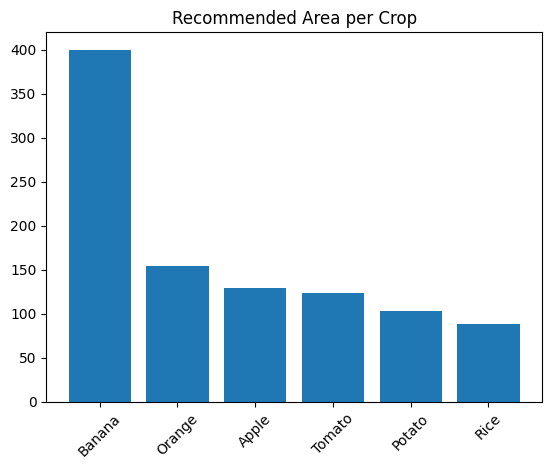

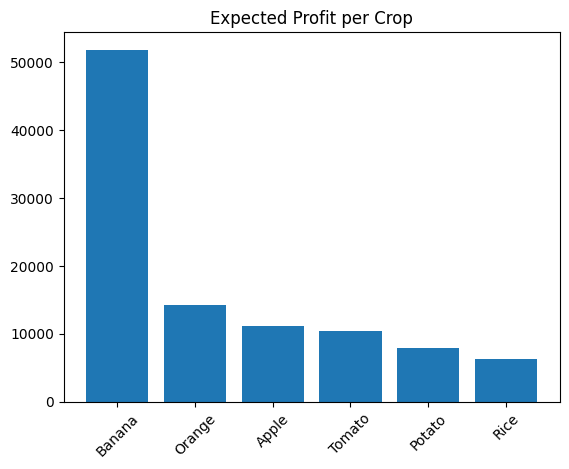

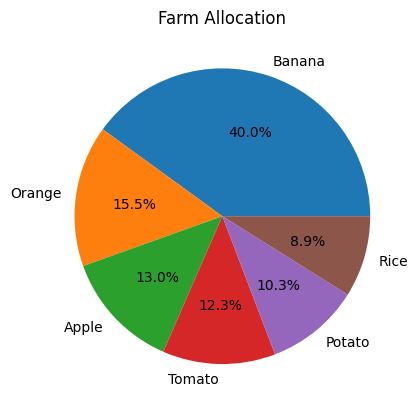

In [34]:
# ==============================
# CLEAN PLOTS
# ==============================

import matplotlib.pyplot as plt

# Area plot
plt.figure()
plt.bar(result_df["crop"], result_df["area"])
plt.xticks(rotation=45)
plt.title("Recommended Area per Crop")
plt.show()

print()
# Profit plot
plt.figure()
plt.bar(result_df["crop"], result_df["total_profit_crop"])
plt.xticks(rotation=45)
plt.title("Expected Profit per Crop")
plt.show()

print()
# Pie chart
plt.figure()
plt.pie(result_df["area"], labels=result_df["crop"], autopct='%1.1f%%')
plt.title("Farm Allocation")
plt.show()